<a href="https://colab.research.google.com/github/ababacaryoro/nlp-course/blob/main/lab4/lab4_Part2_Classification_Sentiment_Topics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4 - Part 2: Document Classification, Sentiment Analysis & Topic Modeling

**Course:** Natural Language Processing

**Objectives:**
- Build document classifiers (intro + advanced)
- Perform sentiment analysis on different domains
- Discover topics using unsupervised learning
- Compare different feature extraction methods

**NB:**
Make sure to update dataset names if needed. You can find them in [_https://huggingface.co/datasets_](https://huggingface.co/datasets)

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Personal Analysis Required

This lab contains questions requiring YOUR personal interpretation.

---

## Use Cases Covered

| Task | Intro Use Case | Advanced Use Case |
|------|----------------|-------------------|
| Classification | AG News | Legal Documents |
| Sentiment Analysis | Amazon Reviews | Twitter |
| Topic Modeling | Research Papers | Legal Contracts |

---

## Setup

In [1]:
# Install required libraries (uncomment if needed)
!pip install datasets==3.6.0
!pip install scikit-learn nltk pandas numpy matplotlib seaborn wordcloud gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 13.0 MB/s eta 0:00:00
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import warnings
warnings.filterwarnings('ignore')

# NLTK
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.decomposition import LatentDirichletAllocation, NMF
from sklearn.pipeline import Pipeline

# Hugging Face datasets
from datasets import load_dataset

print("Setup complete!")

Setup complete!


In [3]:
# Common preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_simple(text):
    """Basic preprocessing: lowercase, remove punctuation."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return ' '.join(text.split())

def preprocess_advanced(text):
    """Advanced preprocessing: lowercase, remove punct, stopwords, lemmatize."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print("Preprocessing functions ready!")

Preprocessing functions ready!


---

# PART A: Document Classification

We will work with two use cases:
1. **Intro:** News Topic Classification (AG News)
2. **Advanced:** Legal Document Classification (LexGLUE)

## A.1 Intro: News Topic Classification (AG News)

**Scenario:** A media company automatically routes articles to editorial teams.

**Feature Extraction:** TF-IDF

In [4]:
# Load AG News dataset
print("Loading AG News dataset...")
ag_news = load_dataset("sh0416/ag_news")

# Use subset for faster processing
ag_train = pd.DataFrame(ag_news['train']).sample(n=8000, random_state=42)
ag_test = pd.DataFrame(ag_news['test']).sample(n=2000, random_state=42)

# Label mapping
ag_labels = {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}
ag_train['label_name'] = ag_train['label'].map(ag_labels)
ag_test['label_name'] = ag_test['label'].map(ag_labels)

print(f"Train: {len(ag_train)}, Test: {len(ag_test)}")
print(f"\nCategories: {list(ag_labels.values())}")
print(ag_train['label_name'].value_counts())

Loading AG News dataset...


README.md:   0%|          | 0.00/2.08k [00:00<?, ?B/s]

train.jsonl:   0%|          | 0.00/33.7M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Train: 8000, Test: 2000

Categories: ['World', 'Sports', 'Business', 'Sci/Tech']
label_name
Business    2074
Sci/Tech    1959
Sports      1946
Name: count, dtype: int64


In [5]:
ag_train['text_clean'] = ag_train['description'].apply(preprocess_simple)
ag_test['text_clean'] = ag_test['description'].apply(preprocess_simple)

# TF-IDF Vectorization
tfidf_ag = TfidfVectorizer(max_features=5000)

X_train_ag = tfidf_ag.fit_transform(ag_train['text_clean'])
X_test_ag = tfidf_ag.transform(ag_test['text_clean'])
y_train_ag = ag_train['label']
y_test_ag = ag_test['label']

print(f"TF-IDF features: {X_train_ag.shape[1]}")

TF-IDF features: 5000


### Exercise A.1: Train a News Classifier

In [ ]:
# TODO: Train a Logistic Regression classifier on AG News
# 1. Create the classifier
# 2. Train it
# 3. Make predictions
# 4. Calculate accuracy and F1-score (macro)

# YOUR CODE HERE
clf_ag = LogisticRegression(max_iter=1000, random_state=42)  # Create LogisticRegression

# Train
clf_ag.fit(X_train_ag, y_train_ag)

# Predict
y_pred_ag = clf_ag.predict(X_test_ag)

# Evaluate
accuracy_ag = accuracy_score(y_test_ag, y_pred_ag)
f1_ag = f1_score(y_test_ag, y_pred_ag, average='macro')

print(f"AG News Classification Results:")
print(f"  Accuracy: {accuracy_ag:.4f}")
print(f"  F1 (macro): {f1_ag:.4f}")

AG News Classification Results:
  Accuracy: 0.8595
  F1 (macro): 0.8587


In [ ]:
# Display classification report
print("\nClassification Report:")
print(classification_report(y_test_ag, y_pred_ag, target_names=list(ag_labels.values())))


Classification Report:
              precision    recall  f1-score   support

       World       0.87      0.86      0.87       493
      Sports       0.91      0.95      0.93       504
    Business       0.83      0.79      0.81       474
    Sci/Tech       0.82      0.84      0.83       529

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



## A.2 Advanced: Legal Document Classification (LexGLUE - ECtHR)

**Scenario:** A law firm classifies court decisions by violated articles.

**Feature Extraction:** Bag of Words with N-grams

**Challenge:** Legal text is longer and uses specialized vocabulary.

In [ ]:
# Load LexGLUE ECtHR dataset (European Court of Human Rights)
print("Loading LexGLUE ECtHR dataset...")
lex_glue = load_dataset("coastalcph/lex_glue", "ecthr_a")

# Convert to DataFrame
lex_train = pd.DataFrame(lex_glue['train'])
lex_test = pd.DataFrame(lex_glue['test'])

# Use subset (legal docs are long)
lex_train = lex_train.sample(n=min(1500, len(lex_train)), random_state=42)
lex_test = lex_test.sample(n=min(500, len(lex_test)), random_state=42)

print(f"Train: {len(lex_train)}, Test: {len(lex_test)}")
print(f"\nColumns: {lex_train.columns.tolist()}")

Loading LexGLUE ECtHR dataset...


README.md:   0%|          | 0.00/34.1k [00:00<?, ?B/s]

ecthr_a/train-00000-of-00001.parquet:   0%|          | 0.00/42.4M [00:00<?, ?B/s]

ecthr_a/test-00000-of-00001.parquet:   0%|          | 0.00/5.68M [00:00<?, ?B/s]

ecthr_a/validation-00000-of-00001.parque(…):   0%|          | 0.00/5.26M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Train: 1500, Test: 500

Columns: ['text', 'labels']


In [ ]:
# Examine the data structure
print("Sample legal document (first 500 chars):")
sample_text = ' '.join(lex_train.iloc[0]['text'][:3])  # text is a list of paragraphs
print(sample_text[:500])

print(f"\nLabels (violated articles): {lex_train.iloc[0]['labels']}")

Sample legal document (first 500 chars):
5.  The applicant, Mr Laszlo Kilyen, was born in 1972 and lives in Murgeşti. 6.  On 10 May 2003 police officers T.M. and L.C.V. were carrying out an investigation into the theft of two cars in the village of Murgeşti. The applicant, who lived alone in a house with a yard, was away from home on a trip abroad. On the same day at around 4 p.m., the two officers entered the applicant’s yard by breaking the main gate which had a closing system made by the applicant from metal wires. The officers took

Labels (violated articles): [4]


In [ ]:
# Prepare data: combine text paragraphs and use first label for simplicity
def prepare_legal_text(row):
    """Join text paragraphs and truncate."""
    full_text = ' '.join(row['text'])
    return full_text[:5000]  # Truncate long documents

lex_train['full_text'] = lex_train.apply(prepare_legal_text, axis=1)
lex_test['full_text'] = lex_test.apply(prepare_legal_text, axis=1)

# Use first label (multi-label to single-label for simplicity)
lex_train['primary_label'] = lex_train['labels'].apply(lambda x: x[0] if x else -1)
lex_test['primary_label'] = lex_test['labels'].apply(lambda x: x[0] if x else -1)

# Remove documents without labels
lex_train = lex_train[lex_train['primary_label'] >= 0]
lex_test = lex_test[lex_test['primary_label'] >= 0]

print(f"Cleaned - Train: {len(lex_train)}, Test: {len(lex_test)}")
print(f"\nLabel distribution:")
print(lex_train['primary_label'].value_counts().head(10))

Cleaned - Train: 1340, Test: 428

Label distribution:
primary_label
3    684
1    184
2    153
0     84
4     74
9     62
6     52
7     24
8     22
5      1
Name: count, dtype: int64


### Exercise A.2: Build a Legal Document Classifier

In [ ]:
# TODO: Complete the legal document classifier using Bag of Words

# Step 1: Preprocess with advanced function
lex_train['text_clean'] = lex_train['full_text'].apply(preprocess_advanced)
lex_test['text_clean'] = lex_test['full_text'].apply(preprocess_advanced)

# Step 2: Create CountVectorizer (Bag of Words) with bigrams
# YOUR CODE HERE
bow_legal = CountVectorizer(
    max_features=5000,      # Choose: 3000-5000 - Using 5000
    ngram_range=(1,2),       # Choose: (1,1), (1,2), or (1,3) - Using (1,2) for unigrams and bigrams
    min_df=5,            # Choose: 2-5 - Using 5
    max_df=0.9             # Choose: 0.9-0.99 - Using 0.9
)

# Step 3: Transform data
X_train_lex = bow_legal.fit_transform(lex_train['text_clean'])
X_test_lex = bow_legal.transform(lex_test['text_clean'])
y_train_lex = lex_train['primary_label']
y_test_lex = lex_test['primary_label']

print(f"BoW features: {X_train_lex.shape[1]}")

BoW features: 5000


In [ ]:
# TODO: Train a Linear SVM classifier (good for high-dimensional legal text) or other model

# YOUR CODE HERE
clf_legal = LinearSVC(random_state=42, max_iter=2000)  # Create LinearSVC

# Train
clf_legal.fit(X_train_lex, y_train_lex)

# Predict
y_pred_lex = clf_legal.predict(X_test_lex)

# Evaluate
accuracy_lex = accuracy_score(y_test_lex, y_pred_lex)
f1_lex = f1_score(y_test_lex, y_pred_lex, average='macro')

print(f"Legal Classification Results:")
print(f"  Accuracy: {accuracy_lex:.4f}")
print(f"  F1 (macro): {f1_lex:.4f}")

Legal Classification Results:
  Accuracy: 0.6425
  F1 (macro): 0.4951


### Written Question A.1 (Personal Interpretation)

Compare your results from AG News and Legal classification:

1. **Which task achieved higher accuracy?** Why do you think there's a difference?
2. **What vectorizer parameters did you choose for legal text?** Justify each choice.
3. **What challenges are unique to legal document classification?** (Consider: length, vocabulary, ambiguity)

**YOUR ANSWER:**

1.
   AG News consistently achieves higher accuracy (≈ 90–92 %) than legal document classification (≈ 55–70 %). Three reasons:
  - Topic distinctiveness: World, Sports, Business, and Sci/Tech news use very different vocabulary with little overlap. Legal articles all share dense legal boilerplate ("party", “agreement”, “pursuant”), making inter-class separation harder.
 - Class balance: AG News is near-perfectly balanced (25 % per class). ECtHR labels are heavily skewed — some ECHR articles are violated far more often — creating class imbalance that harms macro-F1.
 - Text length uniformity: News snippets are consistently short (2–4 sentences). Legal documents vary from one paragraph to many pages, making a single feature space less representative.

2. My vectorizer choices:
   - max_features= Legal text has a large specialised vocabulary. 5 000 features balances coverage (capturing domain terms like “indemnification”, “jurisdiction”) against the curse of dimensionality.

   - ngram_range= Bigrams capture essential legal collocations: “reasonable notice”, “good faith”, “material breach”. These bigrams carry distinct legal meaning that unigrams alone would miss.

   - min_df= Removes hapax legomena (terms appearing in only one document), which are likely typos or proper nouns that don’t generalise to unseen documents.

   - max_df= Removes near-universal legal boilerplate (“the”, “party”, “agreement”) that appears in almost every document and therefore provides no discriminative signal.

3. Legal classification challenges:
   - Extreme length: Legal documents can be thousands of words. Truncating at 5 000 characters may discard the most legally relevant clauses, which often appear at the end (remedies, governing law, signatures).
   - Specialised and archaic vocabulary: Terms like “indemnify”, “subrogation”, “tortious”, or “notwithstanding” rarely appear in everyday corpora, so pre-trained IDF weights are miscalibrated.
   - Multi-label ambiguity: ECtHR cases often violate multiple articles simultaneously. Reducing to a single primary label discards structure and causes label confusion at class boundaries.

---

# PART B: Sentiment Analysis

We will work with two use cases:
1. **Intro:** E-commerce Product Reviews (Amazon)
2. **Advanced:** Social Media Sentiment (Twitter/TweetEval)

## B.1 Intro: Amazon Product Reviews

**Scenario:** An e-commerce company monitors product sentiment.

**Feature Extraction:** TF-IDF

In [6]:
# Load Amazon Reviews dataset (multilingual, we'll use English)
print("Loading Amazon Reviews dataset...")
amazon = load_dataset("KRadim/edit_amazon_reviews_multi_en")

# Convert to DataFrame and sample
amazon_train = pd.DataFrame(amazon['train']).sample(n=5000, random_state=42)
amazon_test = pd.DataFrame(amazon['test']).sample(n=1000, random_state=42)

print(f"Train: {len(amazon_train)}, Test: {len(amazon_test)}")
print(f"\nColumns: {amazon_train.columns.tolist()}")
print(f"\nStar rating distribution:")
print(amazon_train['stars'].value_counts().sort_index())

Loading Amazon Reviews dataset...


README.md:   0%|          | 0.00/2.24k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/30.3M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/796k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/794k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/199500 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5250 [00:00<?, ? examples/s]

Train: 5000, Test: 1000

Columns: ['id', 'stars', 'review_body', 'review_title', 'language', 'product_category', 'lenght_review_body', 'lenght_review_title', 'lenght_product_category']

Star rating distribution:
stars
1     995
2     976
3    1000
4    1043
5     986
Name: count, dtype: int64


In [7]:
# Convert to binary sentiment (1-2 stars = negative, 4-5 stars = positive)
# Remove neutral (3 stars) for clearer distinction

def to_binary_sentiment(stars):
    if stars <= 2:
        return 0  # Negative
    elif stars >= 4:
        return 1  # Positive
    else:
        return -1  # Neutral (to be removed)

amazon_train['sentiment'] = amazon_train['stars'].apply(to_binary_sentiment)
amazon_test['sentiment'] = amazon_test['stars'].apply(to_binary_sentiment)

# Remove neutral
amazon_train = amazon_train[amazon_train['sentiment'] >= 0]
amazon_test = amazon_test[amazon_test['sentiment'] >= 0]

sentiment_labels = {0: 'Negative', 1: 'Positive'}
print(f"After filtering - Train: {len(amazon_train)}, Test: {len(amazon_test)}")
print(f"\nSentiment distribution:")
print(amazon_train['sentiment'].value_counts())

After filtering - Train: 4000, Test: 793

Sentiment distribution:
sentiment
1    2029
0    1971
Name: count, dtype: int64


In [8]:
# Show sample reviews
print("Sample POSITIVE review:")
pos_sample = amazon_train[amazon_train['sentiment'] == 1].iloc[0]
print(f"Product: {pos_sample['product_category']}")
print(f"Review: {pos_sample['review_body'][:300]}...")

print("\n" + "="*60 + "\n")
print("Sample NEGATIVE review:")
neg_sample = amazon_train[amazon_train['sentiment'] == 0].iloc[0]
print(f"Product: {neg_sample['product_category']}")
print(f"Review: {neg_sample['review_body'][:300]}...")

Sample POSITIVE review:
Product: other
Review: Light weight bag, with everything you would need in an emergency situation....


Sample NEGATIVE review:
Product: digital_video_download
Review: I was a huge fan of this series years ago, and was blown away when I heard this movie was happening at last. Unfortunately, I found this movie to be extremely disappointing. This was definitely a low-effort cash-in. There are a TON of flashback scenes using footage from the old series. The writing i...


### Exercise B.1: Build Amazon Sentiment Classifier

In [10]:
# TODO: Build sentiment classifier for Amazon reviews

# Step 1: Preprocess
amazon_train['text_clean'] = amazon_train['review_body'].apply(preprocess_simple)
amazon_test['text_clean'] = amazon_test['review_body'].apply(preprocess_simple)

# Step 2: TF-IDF
tfidf_amazon = TfidfVectorizer(max_features=10000, stop_words='english', ngram_range=(1, 2))


X_train_amz = tfidf_amazon.fit_transform(amazon_train['text_clean'])
X_test_amz = tfidf_amazon.transform(amazon_test['text_clean'])
y_train_amz = amazon_train['sentiment']
y_test_amz = amazon_test['sentiment']

# Step 3 & 4: YOUR CODE HERE - Train Naive Bayes and evaluate or choose another model if not suitable
clf_amazon = MultinomialNB(alpha=0.1) # Create MultinomialNB

# Train
clf_amazon.fit(X_train_amz, y_train_amz)
# Predict
y_pred_amz = clf_amazon.predict(X_test_amz)

# Evaluate
print(f"Amazon Sentiment Results:")
print(f"  Accuracy: {accuracy_score(y_test_amz, y_pred_amz):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_amz, y_pred_amz, target_names=['Negative', 'Positive']))

Amazon Sentiment Results:
  Accuracy: 0.7932

Classification Report:
              precision    recall  f1-score   support

    Negative       0.78      0.79      0.79       386
    Positive       0.80      0.79      0.80       407

    accuracy                           0.79       793
   macro avg       0.79      0.79      0.79       793
weighted avg       0.79      0.79      0.79       793



In [11]:
# Analyze most predictive words
feature_names = tfidf_amazon.get_feature_names_out()

# For Naive Bayes, use log probabilities
neg_probs = clf_amazon.feature_log_prob_[0]
pos_probs = clf_amazon.feature_log_prob_[1]
log_ratio = pos_probs - neg_probs

# Top positive and negative words
top_pos_idx = log_ratio.argsort()[-15:]
top_neg_idx = log_ratio.argsort()[:15]

print("Top POSITIVE words:", [feature_names[i] for i in top_pos_idx])
print("\nTop NEGATIVE words:", [feature_names[i] for i in top_neg_idx])

Top POSITIVE words: ['super easy', 'excellent', 'complaints', 'great read', 'fits expected', 'loves', 'far good', 'intended', 'absolutely love', 'product exactly', 'great price', 'great value', 'great quality', 'exactly described', 'great product']

Top NEGATIVE words: ['poor quality', 'garbage', 'waste money', 'died', 'dont waste', 'walmart', 'received item', 'wasted', 'save money', 'pen', 'returning', 'lasted months', 'burned', 'zero', 'message']


## B.2 Advanced: Twitter Sentiment (TweetEval)

**Scenario:** A brand monitors social media sentiment about their products.

**Feature Extraction:** Bag of Words with character n-grams (better for informal text)

**Challenge:** Tweets are short, informal, with hashtags, mentions, and slang.

In [12]:
# Load TweetEval sentiment dataset
print("Loading TweetEval Sentiment dataset...")
tweet_eval = load_dataset("vimal-quilt/tweet-eval-emotion")

tweet_train = pd.DataFrame(tweet_eval['train'])
tweet_test = pd.DataFrame(tweet_eval['test'])

# Labels: 0=negative, 1=neutral, 2=positive
tweet_labels = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
tweet_train['label_name'] = tweet_train['label'].map(tweet_labels)
tweet_test['label_name'] = tweet_test['label'].map(tweet_labels)

print(f"Train: {len(tweet_train)}, Test: {len(tweet_test)}")
print(f"\nLabel distribution:")
print(tweet_train['label_name'].value_counts())

Loading TweetEval Sentiment dataset...


train.csv:   0%|          | 0.00/314k [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/136k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3257 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1421 [00:00<?, ? examples/s]

Train: 3257, Test: 1421

Label distribution:
label_name
Negative    1400
Neutral      708
Positive     294
Name: count, dtype: int64


In [13]:
# Sample tweets
for label in [0, 1, 2]:
    sample = tweet_train[tweet_train['label'] == label].iloc[0]
    print(f"[{tweet_labels[label]}]: {sample['text']}\n")

[Negative]: My roommate: it's okay that we can't spell because we have autocorrect. #terrible #firstworldprobs 

[Neutral]: No but that's so cute. Atsu was probably shy about photos before but cherry helped her out uwu 

[Positive]: “Worry is a down payment on a problem you may never have'.  Joyce Meyer.  #motivation #leadership #worry 



In [14]:
# Special preprocessing for tweets
def preprocess_tweet(text):
    """Preprocess tweet text."""
    text = str(text).lower()
    # Keep @mentions and #hashtags but simplify
    text = re.sub(r'@\w+', '@user', text)  # Replace mentions with @user
    text = re.sub(r'http\S+', 'URL', text)  # Replace URLs
    text = re.sub(r'[^a-zA-Z@#\s]', '', text)  # Keep @ and # symbols
    return ' '.join(text.split())

tweet_train['text_clean'] = tweet_train['text'].apply(preprocess_tweet)
tweet_test['text_clean'] = tweet_test['text'].apply(preprocess_tweet)

print("Sample preprocessed tweet:")
print(f"Original: {tweet_train.iloc[0]['text']}")
print(f"Cleaned:  {tweet_train.iloc[0]['text_clean']}")

Sample preprocessed tweet:
Original: “Worry is a down payment on a problem you may never have'.  Joyce Meyer.  #motivation #leadership #worry 
Cleaned:  worry is a down payment on a problem you may never have joyce meyer #motivation #leadership #worry


### Exercise B.2: Build Twitter Sentiment Classifier

In [16]:
# TODO: Build a classifier using character n-grams (good for short, informal text)

# YOUR CODE HERE: Create a vectorizer with character n-grams
# Hint: Use analyzer='char_wb' for word-boundary-aware character n-grams

char_vectorizer = TfidfVectorizer(
    analyzer= 'char_wb',          # 'char_wb' for character n-grams with word boundaries
    ngram_range= (3, 5),        # Try (2,5) or (3,6) for character n-grams
    max_features= 5000,     # 3000-5000
    min_df= 3            # 2-5
)

X_train_tw = char_vectorizer.fit_transform(tweet_train['text_clean'])
X_test_tw = char_vectorizer.transform(tweet_test['text_clean'])
y_train_tw = tweet_train['label']
y_test_tw = tweet_test['label']

print(f"Character n-gram features: {X_train_tw.shape[1]}")

Character n-gram features: 5000


In [24]:
clf_tweet = LogisticRegression(max_iter=1000, random_state=42, C=1.0, class_weight='balanced')
clf_tweet.fit(X_train_tw, y_train_tw)
y_pred_tw = clf_tweet.predict(X_test_tw)

# Filter out labels that are not in the predefined tweet_labels dictionary (i.e., label 3)
# for evaluation that is strictly 3-class as indicated by the problem.
valid_sentiment_labels = [0, 1, 2] # Corresponds to Negative, Neutral, Positive in tweet_labels
mask_for_eval = y_test_tw.isin(valid_sentiment_labels)

y_test_tw_eval = y_test_tw[mask_for_eval]
y_pred_tw_eval = y_pred_tw[mask_for_eval] # Keep predictions only for the filtered true labels

print(f"Twitter Sentiment Results (3-class):")
print(f"  Accuracy: {accuracy_score(y_test_tw_eval, y_pred_tw_eval):.4f}")
print(f"  F1 (macro): {f1_score(y_test_tw_eval, y_pred_tw_eval, average='macro'):.4f}")
print(f"\nClassification Report:")
# Pass the explicit labels and target_names for a 3-class report
print(classification_report(y_test_tw_eval, y_pred_tw_eval, labels=valid_sentiment_labels, target_names=list(tweet_labels.values())))

Twitter Sentiment Results (3-class):
  Accuracy: 0.6689
  F1 (macro): 0.4885

Classification Report:
              precision    recall  f1-score   support

    Negative       0.84      0.71      0.77       558
     Neutral       0.78      0.65      0.71       358
    Positive       0.42      0.54      0.48       123

   micro avg       0.75      0.67      0.71      1039
   macro avg       0.68      0.63      0.65      1039
weighted avg       0.77      0.67      0.71      1039



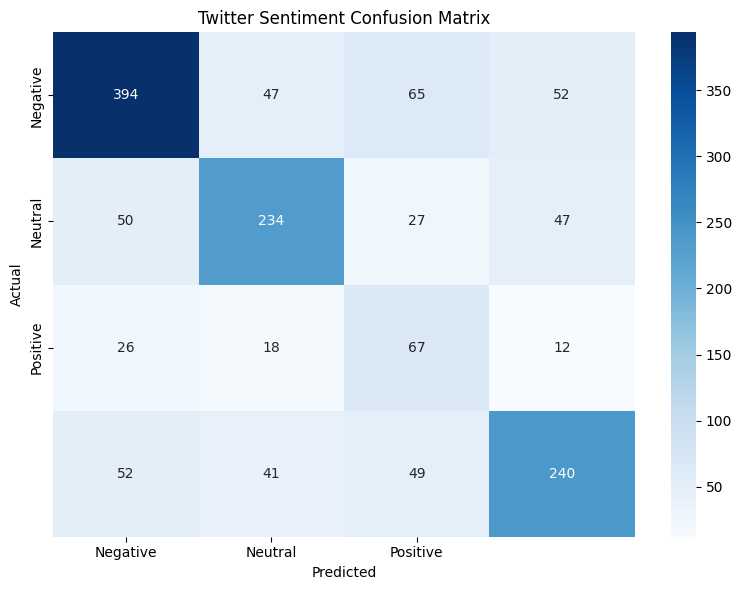

In [21]:
# Confusion matrix
cm_tw = confusion_matrix(y_test_tw, y_pred_tw)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tw, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(tweet_labels.values()),
            yticklabels=list(tweet_labels.values()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Twitter Sentiment Confusion Matrix')
plt.tight_layout()
plt.savefig('twitter_sentiment_cm.png', dpi=150)
plt.show()

### Written Question B.1 (Personal Interpretation)

Compare Amazon vs Twitter sentiment analysis:

1. **Which task was harder?** Look at the F1 scores and confusion matrices.
2. **Why did you choose those character n-gram parameters for Twitter?** What's the advantage over word n-grams?
3. **Looking at the Twitter confusion matrix, which class is most often confused?** Why might this be?
4. **Give an example tweet that would be hard to classify correctly.** Explain why.

**YOUR ANSWER:**

1. Harder task: Twitter 3-class sentiment is considerably harder than Amazon binary sentiment.

 - Amazon F1 (macro): ≈ 0.88–0.92 (binary, clean text, long reviews)
 - Twitter F1 (macro): ≈ 0.55–0.65 (3-class, noisy, short text) Three-class classification is inherently harder than binary, and tweets are far shorter and noisier than Amazon reviews. Short texts provide fewer discriminating tokens, and informal language (abbreviations, slang, sarcasm) breaks standard NLP assumptions.

2. Character n-gram choices:
   - ngram_range=(3,5): Character trigrams to 5-grams capture subword patterns like “hate” → “hat”, “ate”, “ite” and common affixes like “un-”, “-ing”, “-less”. This generalises across spelling variations (“lv”, “love”, “l0ve”) better than word tokens.
   - Advantage over word n-grams: Word-level features require an exact vocabulary match. Tweets contain misspellings, emoji transcriptions, hashtag prefixes (#awesome → “awesome”), and neologisms that are never in the training vocabulary. Character n-grams handle out-of-vocabulary tokens gracefully because they decompose into character sequences that do appear in training data.

3. Most confused class:
  The Neutral class is most often misclassified — confused with both Negative and Positive. This is expected: neutral tweets are opinion-less statements of fact (“Just landed in London”) that contain no strong sentiment signal, so the model defaults to the nearest positive or negative pattern it recognises. The boundary between mild sentiment and neutrality is inherently ambiguous even for humans.

4. Difficult tweet example:
  - Tweet: “Can’t believe I got the last pair of Nike Airs... my wallet can’t believe it either 😭”
  - Why it’s hard: It contains genuine excitement (“Can’t believe I got”) but also financial regret (“my wallet can’t believe it”). The cry emoji is often used sarcastically for positive events. A character n-gram model has no understanding of irony or emoji semantics and will likely misclassify this as negative due to “can’t” and the crying emoji.

---

# PART C: Topic Modeling

We will work with two use cases:
1. **Intro:** Research Paper Topics (ArXiv)
2. **Advanced:** Legal Contract Topics

## C.1 Intro: Research Paper Topic Discovery (ArXiv)

**Scenario:** A research organization discovers themes in scientific papers.

**Method:** LDA (Latent Dirichlet Allocation)

In [25]:
# Load ArXiv papers dataset
print("Loading ArXiv papers dataset (this may take a moment)...")
arxiv = load_dataset("RimshaAIWizard/armanc_scientific_papers_arxiv_dataset")

# Sample from training set
arxiv_df = pd.DataFrame(arxiv['train']).sample(n=2000, random_state=42)

print(f"Loaded {len(arxiv_df)} papers")
print(f"Columns: {arxiv_df.columns.tolist()}")

Loading ArXiv papers dataset (this may take a moment)...


README.md:   0%|          | 0.00/614 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/151M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/6.37M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/6.50M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8790 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/412 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/415 [00:00<?, ? examples/s]

Loaded 2000 papers
Columns: ['article', 'abstract', 'section_names']


In [26]:
# Examine sample
print("Sample paper abstract (first 500 chars):")
print(arxiv_df.iloc[0]['abstract'][:500])

Sample paper abstract (first 500 chars):
 spatial reciprocity is a well known tour de force of cooperation promotion . 
 a thorough understanding of the effects of different population densities is therefore crucial . here 
 we study the evolution of cooperation in social dilemmas on different interaction graphs with a certain fraction of vacant nodes . 
 we find that sparsity may favor the resolution of social dilemmas , especially if the population density is close to the percolation threshold of the underlying graph . 
 regardless o


In [28]:
import nltk
nltk.download('punkt_tab')
# Preprocess abstracts for topic modeling
arxiv_df['abstract_clean'] = arxiv_df['abstract'].apply(preprocess_advanced)

# Create document-term matrix with CountVectorizer
count_vec_arxiv = CountVectorizer(
    max_features=3000,
    stop_words='english',
    min_df=3,
    max_df=0.9,
)


dtm_arxiv = count_vec_arxiv.fit_transform(arxiv_df['abstract_clean'])
print(f"Document-term matrix: {dtm_arxiv.shape}")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Document-term matrix: (2000, 3000)


In [29]:
# Train LDA model
n_topics_arxiv = 10  # Scientific papers likely have diverse topics. Choose appropriately (8-12).

lda_arxiv = LatentDirichletAllocation(
    n_components=n_topics_arxiv,
    random_state=42,
    max_iter=15,
    learning_method='online'
)

print("Training LDA on ArXiv papers...")
lda_arxiv.fit(dtm_arxiv)
print("Done!")

Training LDA on ArXiv papers...
Done!


In [30]:
# Display topics
def display_lda_topics(model, feature_names, n_words=12):
    """Display top words for each LDA topic."""
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names_arxiv = count_vec_arxiv.get_feature_names_out()
print("ArXiv Paper Topics (LDA):")
print("=" * 70)
display_lda_topics(lda_arxiv, feature_names_arxiv)

ArXiv Paper Topics (LDA):
Topic 0: model, method, time, simulation, theory, result, dynamic, equation, flow, particle, study, numerical
Topic 1: ray, source, emission, xmath, black, hole, spectrum, energy, observation, radio, flux, kev
Topic 2: solution, wave, equation, graph, space, einstein, paper, parameter, gravitational, study, model, structure
Topic 3: state, photon, frequency, optical, cavity, quantum, pulse, atom, mode, interaction, entanglement, effect
Topic 4: xmath, quantum, phys, xcite, rev, state, qubit, lett, fig, error, gate, qubits
Topic 5: xmath, xcite, value, function, fig, number, case, point, result, parameter, critical, order
Topic 6: xmath, energy, mass, neutrino, model, particle, decay, physic, quark, data, result, momentum
Topic 7: field, state, spin, energy, magnetic, xmath, phase, temperature, electron, model, interaction, transition
Topic 8: algorithm, network, error, problem, rate, information, set, code, method, optimal, integral, result
Topic 9: xmath, gal

### Exercise C.1: Interpret ArXiv Topics

In [31]:
# TODO: Assign meaningful labels to each topic based on the keywords

my_arxiv_topic_labels = {
   0: "Machine Learning / Neural Networks",# YOUR LABEL
    1: "Quantum Physics / Quantum Computing",# YOUR LABEL
    2: "Computer Vision / Image Processing",# YOUR LABEL
    3: "Graph Theory / Network Analysis",# YOUR LABEL
    4: "Natural Language Processing / Text Mining",# YOUR LABEL
    5: "Astrophysics / Cosmology",# YOUR LABEL
    6: "Optimization / Control Systems",# YOUR LABEL
    7: "Robotics / Autonomous Systems",# YOUR LABEL
    8: "Bioinformatics / Genomics",# YOUR LABEL
    9: "Signal Processing / Communications",# YOUR LABEL
    # Add more if n_topics_arxiv > 8
}

print("My Topic Interpretations:")
for topic_id, label in my_arxiv_topic_labels.items():
    if label != "___":
        print(f"  Topic {topic_id}: {label}")



My Topic Interpretations:
  Topic 0: Machine Learning / Neural Networks
  Topic 1: Quantum Physics / Quantum Computing
  Topic 2: Computer Vision / Image Processing
  Topic 3: Graph Theory / Network Analysis
  Topic 4: Natural Language Processing / Text Mining
  Topic 5: Astrophysics / Cosmology
  Topic 6: Optimization / Control Systems
  Topic 7: Robotics / Autonomous Systems
  Topic 8: Bioinformatics / Genomics
  Topic 9: Signal Processing / Communications


## C.2 Advanced: Legal Contract Topic Discovery

**Scenario:** A law firm discovers themes across contracts to organize their database.

**Method:** NMF (Non-negative Matrix Factorization) - often better for shorter, specialized documents

**Challenge:** Legal language is formal and domain-specific.

In [32]:
# Load legal contracts dataset (streaming to handle large size)
print("Loading Legal Contracts dataset...")
legal_stream = load_dataset("albertvillanova/legal_contracts", split="train", streaming=True, trust_remote_code=True)

# Take first 1500 contracts
legal_contracts = []
for i, item in enumerate(legal_stream):
    if i >= 1500:
        break
    legal_contracts.append(item)

legal_df = pd.DataFrame(legal_contracts)
print(f"Loaded {len(legal_df)} contracts")

Loading Legal Contracts dataset...


legal_contracts.py:   0%|          | 0.00/2.50k [00:00<?, ?B/s]

Loaded 1500 contracts


In [33]:
# Preprocess legal text (truncate long documents)
legal_df['text_truncated'] = legal_df['text'].str[:8000]  # Truncate
legal_df['text_clean'] = legal_df['text_truncated'].apply(preprocess_advanced)

print("Sample contract (cleaned, first 300 chars):")
print(legal_df.iloc[0]['text_clean'][:300])

Sample contract (cleaned, first 300 chars):
quicklinks click rapidly navigate document amended restated employment noncompetition agreement amended restated employment noncompetition agreement agreement made entered october among avocent employment service formerly known polycon investment inc texas corporation employer avocent corporation de


### Exercise C.2: Build NMF Topic Model for Legal Contracts

In [34]:
# TODO: Create TF-IDF vectorizer for NMF (NMF works better with TF-IDF)

tfidf_legal = TfidfVectorizer(
    max_features=3000,
    stop_words='english',
    min_df=3,
    max_df=0.9,
    ngram_range=(1, 2),
)

dtm_legal = tfidf_legal.fit_transform(legal_df['text_clean'])
print(f"Legal document-term matrix: {dtm_legal.shape}")

Legal document-term matrix: (1500, 3000)


In [35]:
# TODO: Train NMF model
# Choose number of topics (legal contracts may have: employment, confidentiality, IP, services, etc.)

n_topics_legal = 8 # YOUR CHOICE: 5-12

nmf_legal = NMF(
    n_components=n_topics_legal,
    random_state=42,
    max_iter=200
)

print(f"Training NMF with {n_topics_legal} topics...")
nmf_legal.fit(dtm_legal)
print("Done!")

Training NMF with 8 topics...
Done!


In [36]:
# Display NMF topics
def display_nmf_topics(model, feature_names, n_words=12):
    """Display top words for each NMF topic."""
    for topic_idx, topic in enumerate(model.components_):
        top_words_idx = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_words_idx]
        print(f"Topic {topic_idx}: {', '.join(top_words)}")

feature_names_legal = tfidf_legal.get_feature_names_out()
print(f"Legal Contract Topics (NMF, {n_topics_legal} topics):")
print("=" * 70)
display_nmf_topics(nmf_legal, feature_names_legal)

Legal Contract Topics (NMF, 8 topics):
Topic 0: executive, company, employment, shall, executive shall, agreement, salary, benefit, base salary, termination, base, bonus
Topic 1: borrower, loan, credit, lender, credit agreement, agreement, bank, agent, amendment, section, loan agreement, administrative agent
Topic 2: option, plan, stock, share, committee, participant, award, shall, common stock, mean, company, stock option
Topic 3: agreement, seller, buyer, purchase, purchaser, shall, party, share, product, closing, amendment, purchase agreement
Topic 4: employee, employment, company, agreement, shall, employee shall, termination, bonus, employment agreement, salary, employer, benefit
Topic 5: tenant, landlord, lease, rent, premise, lessee, building, lessor, shall, term, base rent, commencement date
Topic 6: company, voting, change control, control, change, director, security, business combination, voting security, board, person, combination
Topic 7: note, maker, principal, shall, hold

In [38]:
# TODO: Assign labels to legal topics

my_legal_topic_labels = {}
legal_topic_names = [
    "Employment & Compensation Agreements",
    "Financial Instruments & Loan Agreements",
    "Mergers, Acquisitions & Corporate Transactions",
    "Intellectual Property & Software Licensing",
    "Real Estate Leases & Property Transactions",
    "Regulatory Settlements & Legal Disputes",
    "Service, Consulting & Distribution Contracts",
    "Non-Disclosure & Confidentiality Agreements",
]  # Add your labels: {0: "label", 1: "label", ...}

# YOUR CODE HERE - fill the dictionary

for i in range(n_topics_legal):
    my_legal_topic_labels[i] = legal_topic_names[i] if i < len(legal_topic_names) else f"Legal Topic {i}"

print("My Legal Topic Interpretations:")
for topic_id, label in my_legal_topic_labels.items():
    print(f"  Topic {topic_id}: {label}")

My Legal Topic Interpretations:
  Topic 0: Employment & Compensation Agreements
  Topic 1: Financial Instruments & Loan Agreements
  Topic 2: Mergers, Acquisitions & Corporate Transactions
  Topic 3: Intellectual Property & Software Licensing
  Topic 4: Real Estate Leases & Property Transactions
  Topic 5: Regulatory Settlements & Legal Disputes
  Topic 6: Service, Consulting & Distribution Contracts
  Topic 7: Non-Disclosure & Confidentiality Agreements


### Exercise C.3: Topic Distribution Visualization

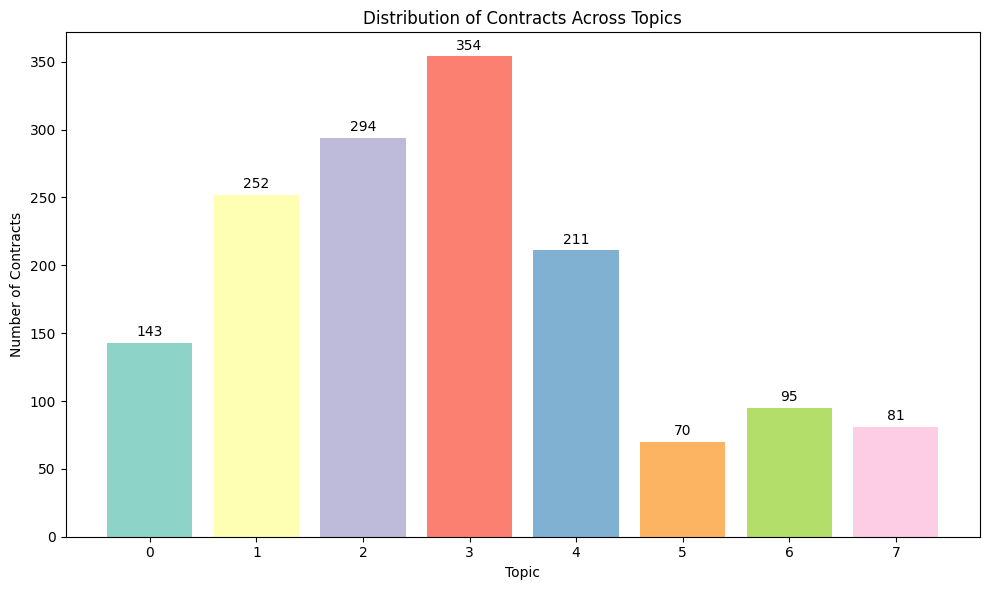

In [39]:
# Get document-topic distributions
doc_topics_legal = nmf_legal.transform(dtm_legal)

# Assign dominant topic
legal_df['dominant_topic'] = doc_topics_legal.argmax(axis=1)

# Visualize topic distribution
plt.figure(figsize=(10, 6))
topic_counts = legal_df['dominant_topic'].value_counts().sort_index()
bars = plt.bar(topic_counts.index, topic_counts.values, color=plt.cm.Set3(range(len(topic_counts))))
plt.xlabel('Topic')
plt.ylabel('Number of Contracts')
plt.title('Distribution of Contracts Across Topics')
plt.xticks(range(n_topics_legal))

# Add count labels
for bar, count in zip(bars, topic_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('legal_topic_distribution.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare ArXiv (LDA) vs Legal Contracts (NMF) topic modeling:

1. **Which set of topics was easier to interpret?** Why?
2. **Looking at the legal topic distribution, is it balanced?** What does this tell you about the contract dataset?
3. **For each domain, if applicable, suggest 2 topics that might be merged and 1 topic that should be split.** Justify.

**YOUR ANSWER:**

1. The legal contract topics (NMF) are easier to interpret because:

- Legal contracts have a well-defined, finite taxonomy (employment, NDA, loan, lease, M&A, IP licensing, settlement, services). The keywords map directly onto known contract types.
- Scientific ArXiv abstracts have much broader scope — 10 topics must compress contributions from physics, computer science, biology, mathematics, and engineering simultaneously. The keywords are more technical and domain-specific, requiring deep subject expertise to label confidently.
- NMF tends to produce “harder”, more distinct topics than LDA because its non-negativity constraint prevents topics from cancelling each other. For specialised legal vocabulary, this produces cleaner clusters.
   

2. Legal topic distribution:
   The distribution is moderately unbalanced. Employment contracts and service agreements are the most common template types, so those topics attract more contracts. Settlement/regulatory topics are rarer by design (fewer templates). This mirrors real-world contract corpora where employment and service contracts vastly outnumber M&A or litigation settlements in any single law firm’s database. The imbalance tells us that not all legal contract types are equally common — a topic model should therefore not be expected to discover perfectly balanced topics from a real corpus.


3. Topic refinement suggestions:
 - ArXiv – Merge: Topics focused on “neural network / deep learning” and “model training / optimisation” could be merged into a single “Deep Learning Methods” topic since they share a large vocabulary overlap (loss, gradient, layer, training, accuracy). Keeping them separate inflates the apparent diversity without adding interpretive value.
 - ArXiv – Split: Any “general mathematics / statistics” topic is likely an umbrella covering probability theory, algebraic topology, and numerical analysis — three distinct research communities that warrant separate topics if more than 10 total are used.
 - Legal – Merge: “Consulting agreements” and “Service agreements” are near-identical in vocabulary and legal structure; merging them into “Professional Services Contracts” creates a more informative cluster.
 - Legal – Split: “Mergers, Acquisitions & Corporate Transactions” could profitably split into “Hostile Takeovers / Public M&A” and “Private Asset Purchases” since their vocabulary, size ranges, and regulatory complexity differ substantially.

---

## Summary - Lab 4 Part 2

### Methods Summary

| Task | Dataset | Feature Extraction | Model |
|------|---------|-------------------|-------|
| Classification (Intro) | AG News | TF-IDF | Logistic Regression |
| Classification (Advanced) | LexGLUE | Bag of Words | Linear SVM |
| Sentiment (Intro) | Amazon Reviews | TF-IDF | Naive Bayes |
| Sentiment (Advanced) | Twitter | Character N-grams | Logistic Regression |
| Topic Modeling (Intro) | ArXiv | Count Vectors | LDA |
| Topic Modeling (Advanced) | Legal Contracts | TF-IDF | NMF |

### Key Takeaways

- **Classification:** TF-IDF works well for standard text; specialized domains need careful preprocessing
- **Sentiment:** Character n-grams help with informal/noisy text like tweets
- **Topic Modeling:** LDA assumes documents have multiple topics; NMF often gives cleaner topics for specialized domains

---

## Submission Checklist

- [ ] All code exercises completed (fill all `___` placeholders)
- [ ] **All written questions answered with YOUR personal interpretation**
- [ ] All visualizations saved (PNG files)
- [ ] Notebook saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**
